# 08 — Results Summary
Loads `results/all_results.csv` and produces the consolidated tables for the report (≤5 tables).

In [7]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils import load_results

df = load_results()
print(f'{len(df)} experiments logged')
display(df)

31 experiments logged


,task,approach,preprocessing,accuracy,precision,recall,f1,notes
0,2.1.1,TextBlob,"raw text, polarity > 0 → pos",0.7000,0.6399,0.9442,0.7628,NaN
1,2.1.1,VADER,"raw text, compound >= 0.05 → pos",0.7015,0.6604,0.8562,0.7456,Designed for short text; long IMDB reviews may...
2,2.1.1,Stanza,sentence-level avg sentiment > 1 → pos,0.8335,0.9333,0.7260,0.8167,NaN
3,2.1.2,"DistilBERT (pre-trained, SST-2)",truncation to 512 tokens,0.9000,0.9228,0.8777,0.8997,No fine-tuning; zero-shot transfer from SST-2 ...
4,2.2,NRC Lexicon,"lowercase, lemmatization, no negation",0.6460,0.6160,0.8160,0.7020,tie-break → neg
5,2.2,NRC Lexicon + Negation,"lowercase, lemmatization, negation window=3",0.6550,0.6254,0.8102,0.7059,polarity flipped for tokens within 3 positions...
6,2.2,NRC Lexicon,"lowercase, lemmatization, no negation",0.6460,0.6160,0.8160,0.7020,tie-break → neg
7,2.2,NRC Lexicon + Negation,"lowercase, lemmatization, negation window=3",0.6550,0.6254,0.8102,0.7059,polarity flipped for tokens within 3 positions...
8,2.2,NRC Lexicon,"lowercase, lemmatization, no negation",0.6460,0.6160,0.8160,0.7020,tie-break → neg
9,2.2,NRC Lexicon + Negation,"lowercase, lemmatization, negation window=3",0.6550,0.6254,0.8102,0.7059,polarity flipped for tokens within 3 positions...


## Table 1 — All results (for report)

In [8]:
table = df[['task','approach','accuracy','precision','recall','f1','preprocessing']]\
    .sort_values(['task','accuracy'], ascending=[True, False])
display(table.style.format({'accuracy':'{:.4f}','precision':'{:.4f}',
                             'recall':'{:.4f}','f1':'{:.4f}'}))

# Export as LaTeX for the report
latex = table[['task','approach','accuracy','precision','recall','f1']]\
    .to_latex(index=False, float_format='%.4f', caption='Results on IMDB test set',
              label='tab:results')
print(latex)
with open('../results/table_all_results.tex', 'w') as f:
    f.write(latex)

,task,approach,accuracy,precision,recall,f1,preprocessing
2,2.1.1,Stanza,0.8335,0.9333,0.7260,0.8167,sentence-level avg sentiment > 1 → pos
1,2.1.1,VADER,0.7015,0.6604,0.8562,0.7456,"raw text, compound >= 0.05 → pos"
0,2.1.1,TextBlob,0.7000,0.6399,0.9442,0.7628,"raw text, polarity > 0 → pos"
3,2.1.2,"DistilBERT (pre-trained, SST-2)",0.9000,0.9228,0.8777,0.8997,truncation to 512 tokens
5,2.2,NRC Lexicon + Negation,0.6550,0.6254,0.8102,0.7059,"lowercase, lemmatization, negation window=3"
7,2.2,NRC Lexicon + Negation,0.6550,0.6254,0.8102,0.7059,"lowercase, lemmatization, negation window=3"
9,2.2,NRC Lexicon + Negation,0.6550,0.6254,0.8102,0.7059,"lowercase, lemmatization, negation window=3"
11,2.2,NRC Lexicon + Negation,0.6550,0.6254,0.8102,0.7059,"lowercase, lemmatization, negation window=3"
13,2.2,NRC Lexicon + Negation,0.6550,0.6254,0.8102,0.7059,"lowercase, lemmatization, negation window=3"
15,2.2,NRC Lexicon + Negation,0.6550,0.6254,0.8102,0.7059,"lowercase, lemmatization, negation window=3"


\begin{table}
\caption{Results on IMDB test set}
\label{tab:results}
\begin{tabular}{llrrrr}
\toprule
task & approach & accuracy & precision & recall & f1 \\
\midrule
2.1.1 & Stanza & 0.8335 & 0.9333 & 0.7260 & 0.8167 \\
2.1.1 & VADER & 0.7015 & 0.6604 & 0.8562 & 0.7456 \\
2.1.1 & TextBlob & 0.7000 & 0.6399 & 0.9442 & 0.7628 \\
2.1.2 & DistilBERT (pre-trained, SST-2) & 0.9000 & 0.9228 & 0.8777 & 0.8997 \\
2.2 & NRC Lexicon + Negation & 0.6550 & 0.6254 & 0.8102 & 0.7059 \\
2.2 & NRC Lexicon + Negation & 0.6550 & 0.6254 & 0.8102 & 0.7059 \\
2.2 & NRC Lexicon + Negation & 0.6550 & 0.6254 & 0.8102 & 0.7059 \\
2.2 & NRC Lexicon + Negation & 0.6550 & 0.6254 & 0.8102 & 0.7059 \\
2.2 & NRC Lexicon + Negation & 0.6550 & 0.6254 & 0.8102 & 0.7059 \\
2.2 & NRC Lexicon + Negation & 0.6550 & 0.6254 & 0.8102 & 0.7059 \\
2.2 & NRC Lexicon + Negation & 0.6550 & 0.6254 & 0.8102 & 0.7059 \\
2.2 & NRC Lexicon & 0.6460 & 0.6160 & 0.8160 & 0.7020 \\
2.2 & NRC Lexicon & 0.6460 & 0.6160 & 0.8160 & 0.7020 \\
2

## Figure — Accuracy across all approaches

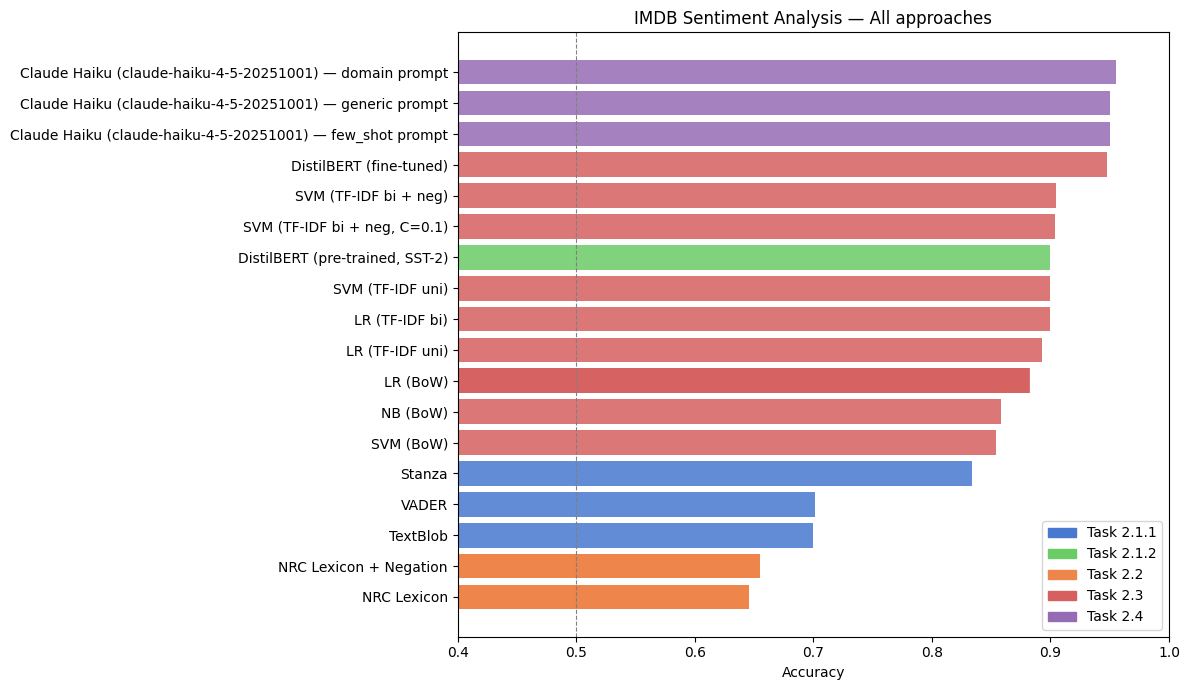

In [9]:
plot_df = df.sort_values('accuracy', ascending=True)

colors = {
    '2.1.1': '#4878D0',
    '2.1.2': '#6ACC65',
    '2.2':   '#EE854A',
    '2.3':   '#D65F5F',
    '2.4':   '#956CB4',
}

fig, ax = plt.subplots(figsize=(12, 7))
for _, row in plot_df.iterrows():
    c = colors.get(str(row['task']), 'gray')
    ax.barh(row['approach'], row['accuracy'], color=c, alpha=0.85)

ax.axvline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Majority baseline')
ax.set_xlabel('Accuracy')
ax.set_title('IMDB Sentiment Analysis — All approaches')
ax.set_xlim(0.4, 1.0)

from matplotlib.patches import Patch
legend_elements = [Patch(color=v, label=f'Task {k}') for k, v in colors.items()]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('../results/fig_all_results.png', dpi=150, bbox_inches='tight')
plt.show()